In [ ]:
import pandas as pd
import numpy as np

# Set random seed
np.random.seed(42)

# Number of rows
n = 300

# Categories
countries = ['USA','Germany','China','Russia','UK','Canada']
industries = ['Manufacturing','Healthcare','Finance','IT','Retail']

Country = np.random.choice(countries, n)
Industry = np.random.choice(industries, n)
Year = np.random.randint(2018, 2026, n)

# Numerical variables
AI_Adoption = np.random.uniform(20, 90, n)

Automation_Risk = AI_Adoption * 0.8 + np.random.normal(0, 5, n)

Job_Displacement = Automation_Risk * 0.6 + np.random.normal(0, 4, n)

New_Job_Creation = AI_Adoption * 0.5 + np.random.normal(0, 3, n)

Economic_Impact = (
    AI_Adoption * 0.4 +
    New_Job_Creation * 0.3 -
    Job_Displacement * 0.2 +
    np.random.normal(0, 5, n)
)

# Create DataFrame
df = pd.DataFrame({
    'Country': Country,
    'Industry': Industry,
    'Year': Year,
    'AI_Adoption_Rate': AI_Adoption,
    'Automation_Risk': Automation_Risk,
    'Job_Displacement': Job_Displacement,
    'New_Job_Creation': New_Job_Creation,
    'Economic_Impact_Index': Economic_Impact
})

df.head(5)


,Country,Industry,Year,AI_Adoption_Rate,Automation_Risk,Job_Displacement,New_Job_Creation,Economic_Impact_Index
0,Russia,Manufacturing,2022,48.021034,38.481830,26.766309,19.401162,13.327050
1,UK,Finance,2022,68.836730,55.377227,35.436433,30.846419,24.333993
2,China,Manufacturing,2023,32.604709,17.617436,10.977518,16.482442,12.754384
3,UK,Retail,2020,68.755103,50.501418,29.204723,29.545018,38.671218
4,UK,Healthcare,2025,48.816285,40.207748,24.966921,22.755961,22.679390


In [ ]:
df.shape

(300, 8)

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                300 non-null    object 
 1   Industry               300 non-null    object 
 2   Year                   300 non-null    int64  
 3   AI_Adoption_Rate       300 non-null    float64
 4   Automation_Risk        300 non-null    float64
 5   Job_Displacement       300 non-null    float64
 6   New_Job_Creation       300 non-null    float64
 7   Economic_Impact_Index  300 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 18.9+ KB


,0
Country,0
Industry,0
Year,0
AI_Adoption_Rate,0
Automation_Risk,0
Job_Displacement,0
New_Job_Creation,0
Economic_Impact_Index,0


In [ ]:
population_mean = df['Job_Displacement'].mean()
population_mean


np.float64(25.704705685552177)

In [ ]:
sample_srs = df['Job_Displacement'].sample(50, random_state=42)
mean_srs = sample_srs.mean()
mean_srs

np.float64(27.898804007051027)

In [ ]:
k = len(df) // 50
sample_systematic = df['Job_Displacement'][::k][:50]
mean_systematic = sample_systematic.mean()
mean_systematic

np.float64(24.333339592217364)

In [ ]:
sample_stratified = df.groupby('Industry')['Job_Displacement']\
                       .apply(lambda x: x.sample(10, random_state=42))\
                       .reset_index(drop=True)

mean_stratified = sample_stratified.mean()
mean_stratified

np.float64(28.107658652447817)

In [ ]:
selected_country = df['Country'].unique()[0]

sample_cluster = df[df['Country'] == selected_country]['Job_Displacement']
mean_cluster = sample_cluster.mean()
mean_cluster

np.float64(26.649352358752594)

In [ ]:
errors = {
    "SRS": abs(mean_srs - population_mean),
    "Systematic": abs(mean_systematic - population_mean),
    "Stratified": abs(mean_stratified - population_mean),
    "Cluster": abs(mean_cluster - population_mean)
}

errors

{'SRS': np.float64(0.6278564323696507),
 'Systematic': np.float64(2.514951923618039),
 'Stratified': np.float64(1.2593671366124148),
 'Cluster': np.float64(0.1989391570828083)}

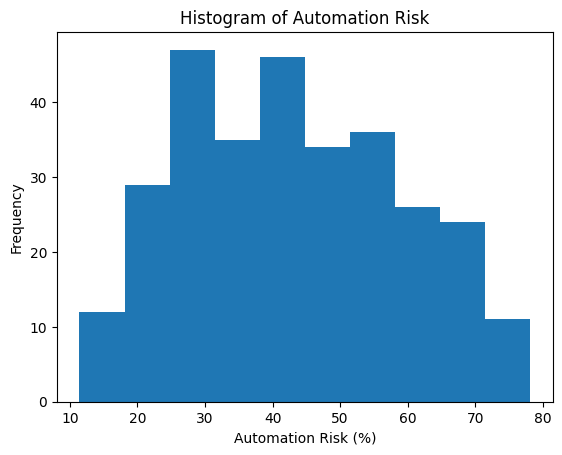

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Automation_Risk'], bins=10)
plt.xlabel("Automation Risk (%)")
plt.ylabel("Frequency")
plt.title("Histogram of Automation Risk")
plt.show()

In [ ]:
#Frequency Table
bins = np.linspace(df['Automation_Risk'].min(),
                   df['Automation_Risk'].max(), 11)

freq_table = pd.cut(df['Automation_Risk'], bins).value_counts().sort_index()

freq_table

,count
Automation_Risk,
"(9.354, 16.907]",13
"(16.907, 24.46]",29
"(24.46, 32.013]",35
"(32.013, 39.567]",32
"(39.567, 47.12]",43
"(47.12, 54.673]",53
"(54.673, 62.226]",43
"(62.226, 69.78]",37
"(69.78, 77.333]",12


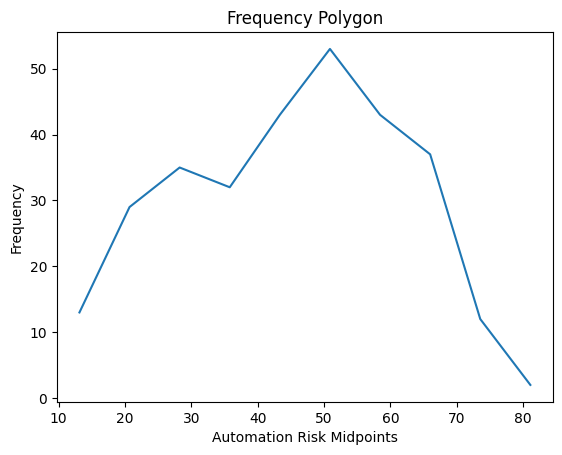

In [ ]:
freq = freq_table.values
midpoints = [interval.mid for interval in freq_table.index]

plt.plot(midpoints, freq)
plt.xlabel("Automation Risk Midpoints")
plt.ylabel("Frequency")
plt.title("Frequency Polygon")
plt.show()

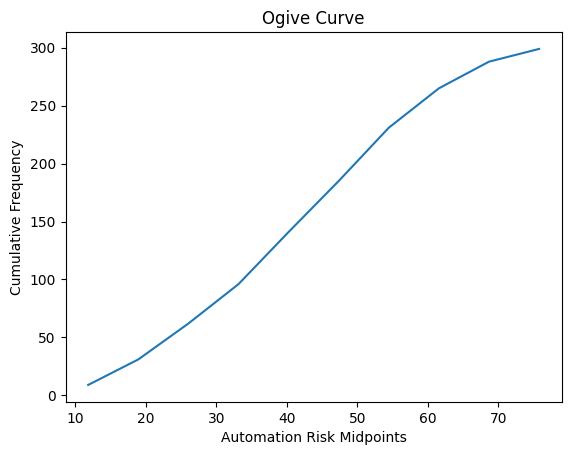

In [ ]:
cumulative = freq_table.cumsum()

plt.plot(midpoints, cumulative)
plt.xlabel("Automation Risk Midpoints")
plt.ylabel("Cumulative Frequency")
plt.title("Ogive Curve")
plt.show()

In [ ]:
#Univariate Analysis
df['AI_Adoption_Rate'].describe()
df['Job_Displacement'].describe()

,Job_Displacement
count,300.000000
mean,26.848292
std,10.530568
min,-3.521868
25%,19.300468
50%,27.446491
75%,34.588711
max,49.791592


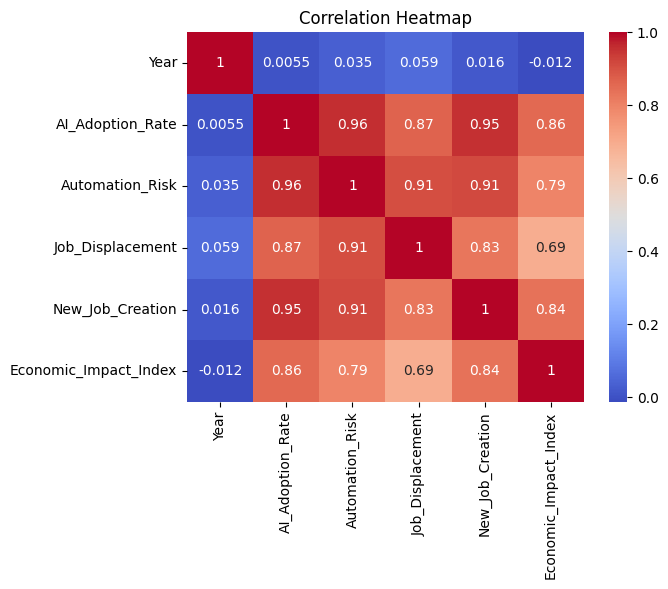

In [ ]:
#Correlation Matrix
corr = df.corr(numeric_only=True)

import seaborn as sns
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

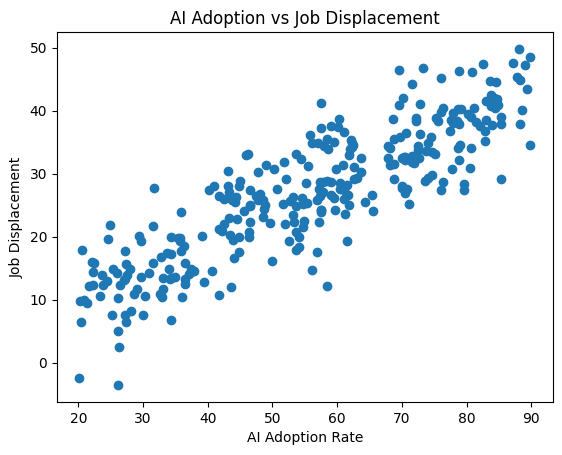

In [ ]:
plt.scatter(df['AI_Adoption_Rate'], df['Job_Displacement'])
plt.xlabel("AI Adoption Rate")
plt.ylabel("Job Displacement")
plt.title("AI Adoption vs Job Displacement")
plt.show()

/tmp/ipython-input-2349085184.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_auto = df.groupby('AI_Bin')['Automation_Risk'].mean()


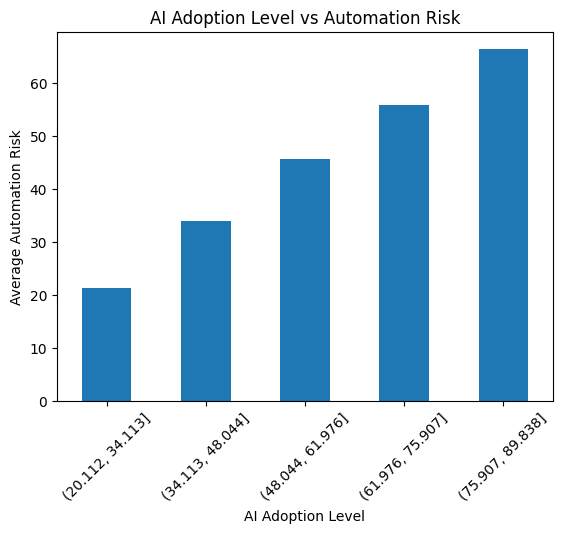

In [ ]:
grouped_auto = df.groupby('AI_Bin')['Automation_Risk'].mean()

plt.figure()
grouped_auto.plot(kind='bar')
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Automation Risk")
plt.title("AI Adoption Level vs Automation Risk")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-247785304.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_njc = df.groupby('AI_Bin')['New_Job_Creation'].mean()


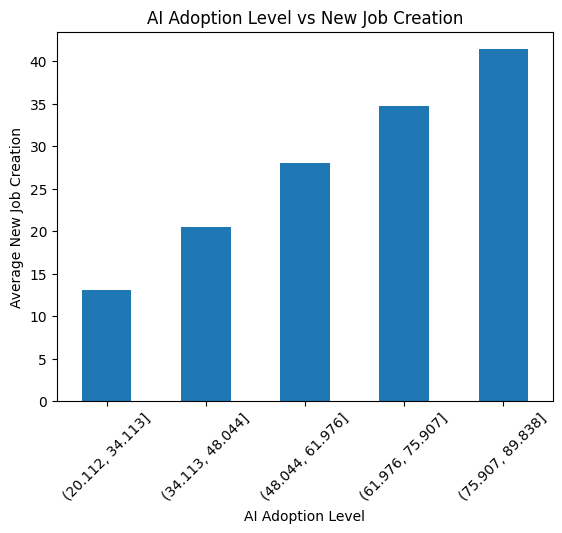

In [ ]:
grouped_njc = df.groupby('AI_Bin')['New_Job_Creation'].mean()

plt.figure()
grouped_njc.plot(kind='bar')
plt.xlabel("AI Adoption Level")
plt.ylabel("Average New Job Creation")
plt.title("AI Adoption Level vs New Job Creation")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-989328150.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('AI_Bin')['Job_Displacement'].mean()


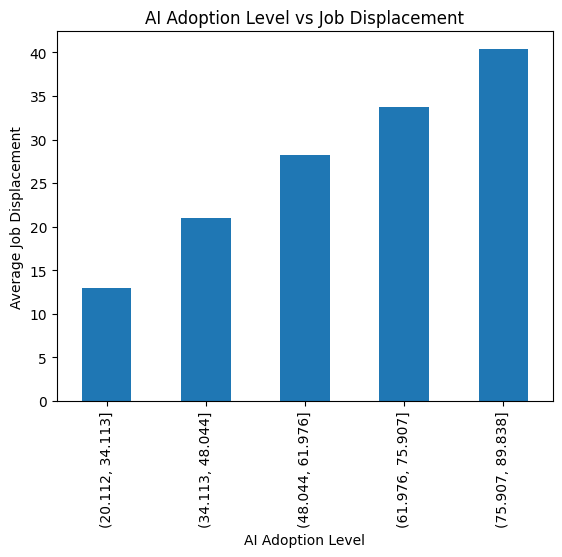

In [ ]:
df['AI_Bin'] = pd.cut(df['AI_Adoption_Rate'], bins=5)

grouped = df.groupby('AI_Bin')['Job_Displacement'].mean()

plt.figure()
grouped.plot(kind='bar')
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Job Displacement")
plt.title("AI Adoption Level vs Job Displacement")
plt.show()

In [ ]:
df['Job_Displacement'].mean()
df['Job_Displacement'].median()
df['Job_Displacement'].mode()

,Job_Displacement
0,-0.119566
1,2.183564
2,3.319358
3,5.594406
4,6.395019
...,...
295,51.384031
296,52.475720
297,52.678502
298,52.907576


In [ ]:
df['Job_Displacement'].var()
df['Job_Displacement'].std()

10.530567689758435

In [ ]:
cv = df['Job_Displacement'].std() / df['Job_Displacement'].mean()
cv

np.float64(0.39222487149870955)

In [ ]:
#Probability Analysis
prob = (df['Job_Displacement'] > 30).mean()
prob

np.float64(0.4)

In [ ]:
(df['AI_Adoption_Rate'] > 70).mean()

np.float64(0.2866666666666667)

In [ ]:
#Bayes Theorem
A = df['AI_Adoption_Rate'] > 70
B = df['Job_Displacement'] > 30

prob_bayes = (A & B).sum() / A.sum()
prob_bayes

np.float64(0.872093023255814)

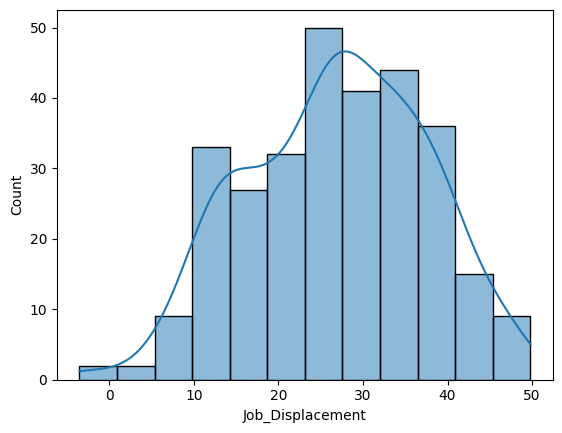

In [ ]:
#Plot Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Job_Displacement'], kde=True)
plt.show()

In [ ]:
mean = df['Job_Displacement'].mean()
std = df['Job_Displacement'].std()

z = (30 - mean) / std
z

np.float64(0.2992914130574185)

In [ ]:
df['AI_Bin'] = pd.cut(df['AI_Adoption_Rate'], bins=5)

/tmp/ipykernel_37099/1557996944.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('AI_Bin')[[


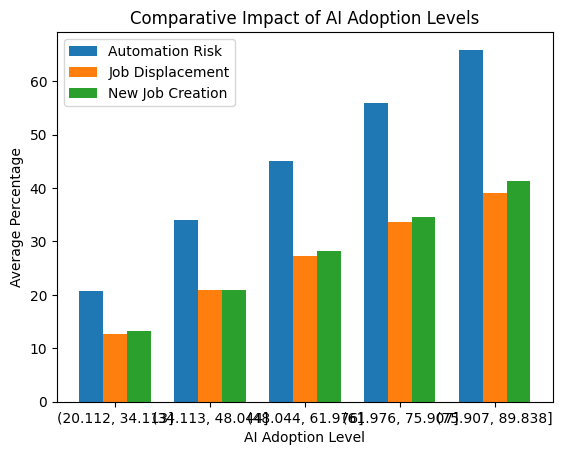

In [ ]:
import numpy as np

grouped = df.groupby('AI_Bin')[[
    'Automation_Risk',
    'Job_Displacement',
    'New_Job_Creation'
]].mean()

x = np.arange(len(grouped.index))
width = 0.25

plt.figure()

plt.bar(x - width, grouped['Automation_Risk'], width, label='Automation Risk')
plt.bar(x, grouped['Job_Displacement'], width, label='Job Displacement')
plt.bar(x + width, grouped['New_Job_Creation'], width, label='New Job Creation')

plt.xticks(x, grouped.index)
plt.xlabel("AI Adoption Level")
plt.ylabel("Average Percentage")
plt.title("Comparative Impact of AI Adoption Levels")
plt.legend()

plt.show()

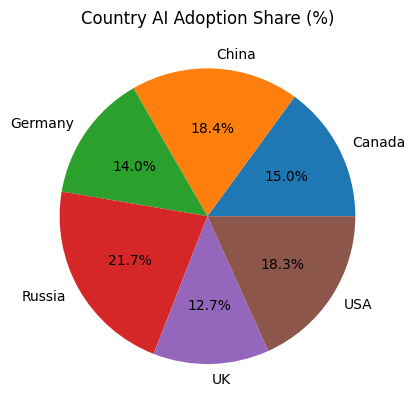

In [ ]:
country_total = df.groupby('Country')['AI_Adoption_Rate'].sum()
country_percent = country_total / country_total.sum() * 100

plt.figure()
plt.pie(country_percent, labels=country_percent.index, autopct='%1.1f%%')
plt.title("Country AI Adoption Share (%)")
plt.show()

In [ ]:
import statsmodels.api as sm

X = df[['AI_Adoption_Rate',
       'Automation_Risk',
       'New_Job_Creation']]

y = df['Job_Displacement']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Job_Displacement   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     465.6
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          1.02e-111
Time:                        14:45:31   Log-Likelihood:                -869.89
No. Observations:                 300   AIC:                             1748.
Df Residuals:                     296   BIC:                             1763.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.6260      0.782      0.800      0.424      -0.913       2.165
AI_Adoption_Rate     0.0260      0.062      0.417      0.677      -0.097       0.149
Automation_Risk      0.5869      0.054     10.836      0.000       0.480       0.694
New_Job_Creation    -0.0490      0.085     -0.578      0.564      -0.216       0.118
==============================================================================
Omnibus:                        0.891   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.641   Jarque-Bera (JB):                1.002
Skew:                           0.098   Prob(JB):                        0.606
Kurtosis:                       2.795   Cond. No.                         248.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""